# Лабораторная работа №3
$$
\begin{cases}
    \frac{dx}{dt}=\frac{p}{n^2}, \frac{dp}{dt}=0 \\
    \frac{dy}{dt}=\frac{q}{n^2}, \frac{dq}{dt}=\frac{n'}{n}
\end{cases}
$$
Условие: $p^2+q^2=n^2(y)$

**Прямая задача:**
$$
X(p)=2p \int_{0}^{n^{-1}(p)} \frac{dy}{\sqrt{n^2(y)-p^2}}, p \in[p_0, n(0)]
$$

**Формула времени:**
$$
T(p)= 2 \int_{0}^{n^{-1}(p)} \frac{n^2(y)}{\sqrt{n^2(y)-p^2}}dy
$$


**Формула Герлоца-Вихерта:**
$$
n^{-1}(r)=\frac{1}{\pi}\int_{r}^{n(0)}\frac{X(p)dp}{\sqrt{p^2-r^2}}, r \in[p_0, n(0)]
$$

Возьмём функцию:
$$
n(y)=10e^{-y}
$$



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad

# Параметры
n0 = 10.0  
p_min = 1e-3 
p_max = n0 

In [12]:
def n(y):
    return n0 * np.exp(-y)

def inverse_n(r):
    """Обратная функция n(y): y такой, что n(y) = r"""
    return -np.log(r / n0)

def X_numeric(p):
    """Численное вычисление X(p) по формуле"""
    y_max = inverse_n(p)
    
    def integrand(y):
        return p / np.sqrt(n(y)**2 - p**2)
    
    result, _ = quad(integrand, 0, y_max, epsabs=1e-8, epsrel=1e-8, limit=100)
    return 2 * result

def T_numeric(p):
    """Численное вычисление T(p) по формуле"""
    y_max = inverse_n(p)
    
    def integrand(y):
        return n(y)**2 / np.sqrt(n(y)**2 - p**2)
    
    result, _ = quad(integrand, 0, y_max, epsabs=1e-8, epsrel=1e-8, limit=100)
    return 2 * result

def ray_ode(t, state, p_val):
    """Система ОДУ для одного луча с фиксированным p"""
    x, y, q = state
    n_val = n(y)
    n_prime = -n_val  # производная n по y
    
    # Уравнения из условия
    dxdt = p_val / (n_val**2)
    dydt = q / (n_val**2)
    dqdt = n_prime / n_val
    
    return [dxdt, dydt, dqdt]

def solve_ray(p, t_max=None):
    """Решить систему ОДУ для луча с параметром p"""
    # Начальные условия
    x0 = 0.0
    y0 = 0.0
    q0 = np.sqrt(n0**2 - p**2)
    t_max = T_numeric(p)
    # Событие для остановки при y=0 (возврат на ось)
    def event_y_zero(t, state, p_val):
        return state[1]
    event_y_zero.terminal = True
    event_y_zero.direction = -1
    
    # Решаем ОДУ
    sol = solve_ivp(ray_ode, [0, t_max*1.1], [x0, y0, q0], 
                    args=(p,), events=[event_y_zero], 
                    max_step=0.01, rtol=1e-8, atol=1e-10)
    
    return sol

def gerlats_vikert(r):
    """Вычисление n^{-1}(r) по формуле Герлоца-Вихерта"""
    
    def integrand(p):
        return X_numeric(p) / np.sqrt(p**2 - r**2)
    
    # Интегрируем от r до n0
    result, _ = quad(integrand, r, n0, epsabs=1e-8, epsrel=1e-8, limit=100)
    return result/np.pi

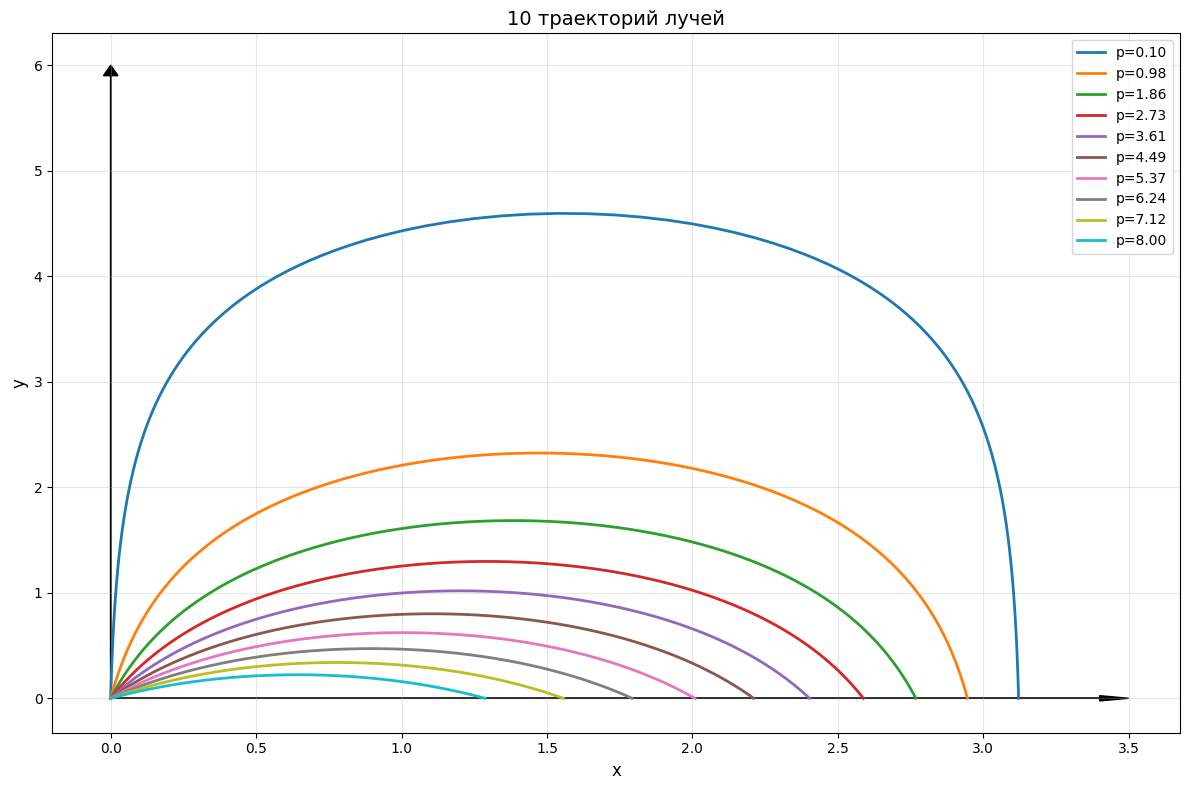

In [6]:
# ========== ПУНКТ 1: 10 кривых, достигающих ось x ==========
plt.figure(figsize=(12, 8))

p_values_10 = np.linspace(p_min + 0.1, n0 - 2.0, 10)

for i, p in enumerate(p_values_10):
    sol = solve_ray(p)
    plt.plot(sol.y[0], sol.y[1], label=f'p={p:.2f}', linewidth=2)
    
plt.arrow(0, 0, 3.5, 0, 
          head_width=0.05, head_length=0.1, 
          fc='black', ec='black', 
          length_includes_head=True,
          width=0.001)

plt.arrow(0, 0, 0, 6, 
          head_width=0.05, head_length=0.1, 
          fc='black', ec='black', 
          length_includes_head=True,
          width=0.001)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('10 траекторий лучей', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

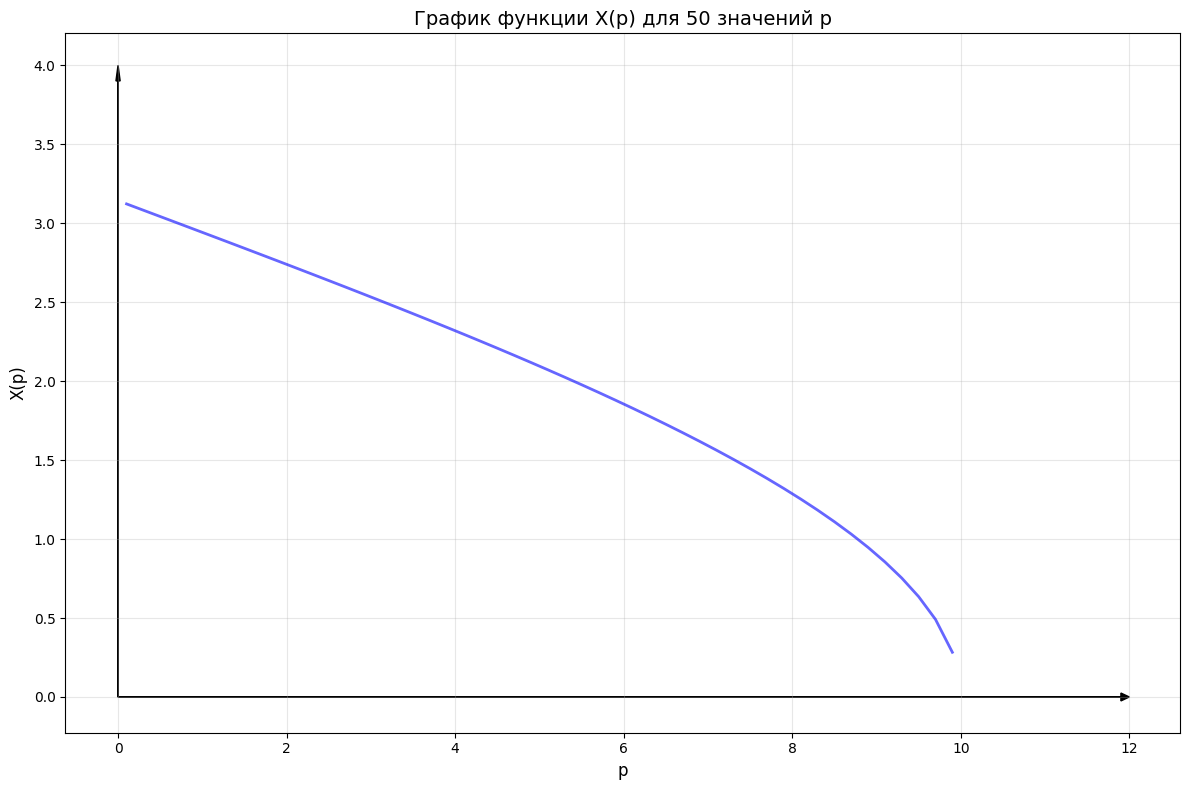

In [87]:
# ========== ПУНКТ 2: 50 лучей при разных p ==========
plt.figure(figsize=(12, 8))

p_values_50 = np.linspace(p_min + 0.1, n0 - 0.1, 50)

X_values = []
for p in p_values_50:
    X_val = X_numeric(p)
    X_values.append(X_val)

plt.plot(p_values_50, X_values, 'b-', alpha=0.6, linewidth=2)

plt.arrow(0, 0, 12, 0, 
          head_width=0.05, head_length=0.1, 
          fc='black', ec='black', 
          length_includes_head=True,
          width=0.001)

plt.arrow(0, 0, 0, 4, 
          head_width=0.05, head_length=0.1, 
          fc='black', ec='black', 
          length_includes_head=True,
          width=0.001)

plt.xlabel('p', fontsize=12)
plt.ylabel('X(p)', fontsize=12)
plt.title('График функции X(p) для 50 значений p', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()

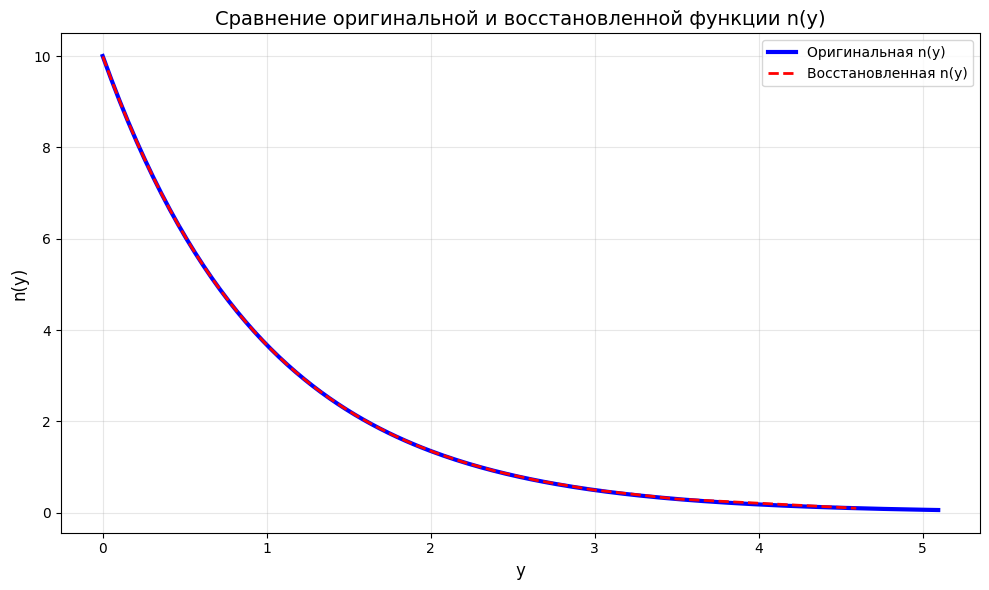

In [ ]:
# ========== ПУНКТ 3: Обратная задача ==========
r_values = np.linspace(p_min + 0.1, n0 - 0.01, 50)

y_reconstructed = []
for r in r_values:
    y_rec = gerlats_vikert(r)
    y_reconstructed.append(y_rec)
y_reconstructed = np.array(y_reconstructed)

y_grid = np.linspace(0, max(y_reconstructed) + 0.5, 50)
n_original_smooth = n(y_grid) 

plt.figure(figsize=(10, 6))
plt.plot(y_grid, n_original_smooth, 'b-', label='Оригинальная n(y)', linewidth=3)

sorted_indices = np.argsort(y_reconstructed)
plt.plot(y_reconstructed[sorted_indices], r_values[sorted_indices], 
         'r--', label='Восстановленная n(y)', linewidth=2)

plt.xlabel('y', fontsize=12)
plt.ylabel('n(y)', fontsize=12)
plt.title('Сравнение оригинальной и восстановленной функции n(y)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()